# TP4 (corregido v2) — Clasificando informales en la EPH
**Big Data y Machine Learning (527) — UBA 2026 · Grupo 1**

Regresión logística, métricas de desempeño y curvas ROC sobre la **matriz X ampliada de 16 variables
(sin ingreso)** construida a partir del TP3. Modelo 1: train 2024. Modelo 2 (MM): especificación
Maurizio & Monsalvo (2021) con la informalidad rezagada `informal_2024`.

In [20]:
## 0. Librerías y configuración

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

plt.rcParams['figure.dpi']        = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.linestyle']    = '--'
plt.rcParams['grid.alpha']        = 0.35
print('Librerías base cargadas.')

Librerías base cargadas.


In [22]:
## 1. Carga de datos y construcción de la base ampliada (matriz del TP3)
## seleccionamos las variables crudas y construimos las características derivadas. La matriz final
## tiene **16 variables, ninguna de ingreso** (ver justificación más abajo).

# ----- Rutas -----
# Los .xlsx están en la carpeta TP4; los gráficos/CSV se guardan en la carpeta actual.
RUTA_TP4 = r'C:\Users\juanc\OneDrive\Escritorio\SQL Training\Big Data y Machine Learning\TP4'
RUTA_OUT = os.getcwd()
RUTA_2024 = os.path.join(RUTA_TP4, 'usu_individual_T324.xlsx')
RUTA_2025 = os.path.join(RUTA_TP4, 'usu_individual_T325.xlsx')
print('Salida:', RUTA_OUT)

Salida: C:\Users\juanc


In [ ]:
# ----- Variables crudas a seleccionar (continúa el TP2/TP3) -----
# NOTA: P21/P47T (ingresos) quedan EXCLUIDOS.
VARS = [
    'CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'PONDERA',
    'CH03', 'CH04', 'CH06', 'CH07', 'CH08',
    'NIVEL_ED', 'ESTADO', 'CAT_OCUP',
    'PP04C', 'PP04D_COD', 'PP07H',
    'PP3E_TOT', 'PP3F_TOT',
    'CH12', 'CH13', 'CH14',
]
eph_2024_raw = pd.read_excel(RUTA_2024)
eph_2025_raw = pd.read_excel(RUTA_2025)
print(f'EPH 2024 T3: {eph_2024_raw.shape[0]:,} personas | EPH 2025 T3: {eph_2025_raw.shape[0]:,} personas')

vars_2024 = [v for v in VARS if v in eph_2024_raw.columns]
vars_2025 = [v for v in VARS if v in eph_2025_raw.columns]
df_2024 = eph_2024_raw[vars_2024].copy(); df_2024['año'] = 2024
df_2025 = eph_2025_raw[vars_2025].copy(); df_2025['año'] = 2025
for df in [df_2024, df_2025]:
    df['CH08'] = pd.to_numeric(df['CH08'], errors='coerce').astype('Int64')
df_total = pd.concat([df_2024, df_2025], ignore_index=True)
print(f'Base total combinada: {len(df_total):,} personas')

## 2. Variables derivadas y características adicionales

| Variable | Fuente EPH | Descripción |
|----------|-----------|-------------|
| `edad`, `edad2` | CH06 | Edad y su cuadrado (perfil de ciclo de vida, forma de U) |
| `educ` | CH12/CH13/CH14 | Años de educación formal |
| `sec_completo` | educ≥12 | Dummy: secundario completo |
| `universitario` | educ≥17 | Dummy: universitario completo |
| `mujer` | CH04=2 | Dummy: mujer |
| `casado` | CH07∈{1,2} | Dummy: casado/unido |
| `jefe_hogar` | CH03=1 | Dummy: jefe/a de hogar |
| `nhogar` | conteo | Miembros del hogar |
| `horastrab` | PP3E_TOT+PP3F_TOT | Horas semanales (TODOS los ocupados) |
| `jornada_completa` | PP3E_TOT≥35 | Dummy: 35+ horas |
| `pluriempleo` | PP3F_TOT>0 | Dummy: segunda ocupación |
| `PP04C` | PP04C | Tamaño del establecimiento *(caveat: parte de la definición)* |
| `sin_cobertura` | CH08=4 | Dummy: sin obra social *(caveat: endógena a la formalidad)* |
| `sector_construccion` | CAES 41–43 | Dummy: construcción (alta informalidad) |
| `sector_comercio` | CAES 45–47 | Dummy: comercio |

> **Corrección respecto del TP3:** (i) `horastrab` se calcula para **todos los ocupados**, no solo
> jefes de hogar (en el TP3, restringirlo a jefes sesgaba la muestra hacia trabajadores más formales);
> (ii) las dummies de sector se construyen con los **2 primeros dígitos del CAES** (`PP04D_COD` es un
> código de 5 dígitos), evitando que queden degeneradas.

In [4]:
# Universo: respondieron la condición de actividad
respondieron = df_total[df_total['ESTADO'] != 0].copy()

# ----- edad y edad² -----
respondieron['edad'] = pd.to_numeric(respondieron['CH06'], errors='coerce')
respondieron['edad'] = respondieron['edad'].where((respondieron['edad'] >= 0) & (respondieron['edad'] <= 120), np.nan)
respondieron['edad2'] = respondieron['edad'] ** 2

# ----- educ: años de educación formal -----
años_base = {1:0, 2:0, 3:0, 4:7, 5:9, 6:12, 7:12, 8:17, 9:0}
años_max  = {1:1, 2:7, 3:9, 4:5, 5:3, 6:5,  7:5,  8:5,  9:0}
def calcular_educ(row):
    try:
        nivel    = int(pd.to_numeric(row.get('CH12', 0), errors='coerce') or 0)
        completo = int(pd.to_numeric(row.get('CH13', 2), errors='coerce') or 2)
        ultimo   = pd.to_numeric(row.get('CH14', 0), errors='coerce'); ultimo = 0 if pd.isna(ultimo) else int(ultimo)
        base = años_base.get(nivel, 0); maximo = años_max.get(nivel, 0)
        return base + maximo if completo == 1 else base + min(ultimo, maximo)
    except: return np.nan
respondieron['educ'] = respondieron.apply(calcular_educ, axis=1)
respondieron['sec_completo']  = (respondieron['educ'] >= 12).astype(float)
respondieron['universitario'] = (respondieron['educ'] >= 17).astype(float)

# ----- horastrab para TODOS los ocupados (corrección del sesgo "solo jefes") -----
respondieron['PP3E_TOT'] = pd.to_numeric(respondieron['PP3E_TOT'], errors='coerce').replace(999, np.nan)
respondieron['PP3F_TOT'] = pd.to_numeric(respondieron['PP3F_TOT'], errors='coerce').replace(999, np.nan).fillna(0)
respondieron['horastrab'] = respondieron['PP3E_TOT'] + respondieron['PP3F_TOT']
respondieron['jornada_completa'] = (respondieron['PP3E_TOT'] >= 35).astype(float)
respondieron['pluriempleo']      = (respondieron['PP3F_TOT'] > 0).astype(float)

# ----- dummies demográficas -----
respondieron['mujer']      = (pd.to_numeric(respondieron['CH04'], errors='coerce') == 2).astype(float)
respondieron['casado']     = (pd.to_numeric(respondieron['CH07'], errors='coerce').isin([1, 2])).astype(float)
respondieron['jefe_hogar'] = (pd.to_numeric(respondieron['CH03'], errors='coerce') == 1).astype(float)
respondieron['sin_cobertura'] = (pd.to_numeric(respondieron['CH08'], errors='coerce') == 4).astype(float)

# ----- nhogar -----
nh = respondieron.groupby(['CODUSU', 'NRO_HOGAR'])['COMPONENTE'].count().reset_index().rename(columns={'COMPONENTE': 'nhogar'})
respondieron = respondieron.merge(nh, on=['CODUSU', 'NRO_HOGAR'], how='left')

# ----- dummies de sector (2 primeros dígitos del CAES PP04D_COD) -----
code = pd.to_numeric(respondieron['PP04D_COD'], errors='coerce')
div = pd.Series(np.nan, index=respondieron.index)
ok = code.notna()
div.loc[ok] = code.loc[ok].astype('int64').astype(str).str[:2].astype(int)
respondieron['caes_div'] = div
respondieron['sector_construccion'] = respondieron['caes_div'].isin([41, 42, 43]).astype(float)
respondieron['sector_comercio']     = respondieron['caes_div'].isin([45, 46, 47]).astype(float)

print('Variables derivadas y adicionales creadas.')

Variables derivadas y adicionales creadas.


In [ ]:
## 3. Indicador de informalidad (Upper-tier informal, Grupo 1)
# **Formal (0):** asalariado (`CAT_OCUP=3`) con descuento jubilatorio (`PP07H=1`)
# **Informal (1):** asalariado (`CAT_OCUP=3`) + sin jubilación (`PP07H=2`) + empresa > 5 (`PP04C≥6`)
# **NaN:** no aplica


def crear_indicador_informalidad(df):
    df = df.copy()
    for col in ['CAT_OCUP', 'PP07H', 'PP04C']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    def clasificar(row):
        if row.get('CAT_OCUP', np.nan) != 3: return np.nan
        if row.get('PP07H', np.nan) not in [1, 2]: return np.nan
        if row.get('PP07H', np.nan) == 1: return 0
        pp04c = row.get('PP04C', np.nan)
        if pd.isna(pp04c) or pp04c == 99: return np.nan
        return 1 if pp04c >= 6 else 0
    df['informal'] = df.apply(clasificar, axis=1)
    return df

ocupados = respondieron[respondieron['ESTADO'] == 1].copy()
ocupados = crear_indicador_informalidad(ocupados)
print(f'Ocupados (2024+2025): {len(ocupados):,}')
print(ocupados[ocupados['informal'].notna()].groupby(['año','informal']).size()
      .rename({0:'Formal',1:'Upper-tier informal'}).unstack())

## 4. Matriz X de 16 variables (sin ingreso) y separación train/test

`ocupados_X_2024` (train), `ocupados_X_2025` (test) y `ocupados_X_2025_MM` (con `informal_2024`
para la especificación de Maurizio & Monsalvo, vía inner join por CODUSU+NRO_HOGAR+COMPONENTE).

In [ ]:
VARS_X = [
    'edad', 'edad2', 'educ', 'sec_completo', 'universitario',
    'mujer', 'casado', 'jefe_hogar', 'nhogar',
    'horastrab', 'jornada_completa', 'pluriempleo', 'PP04C',
    'sin_cobertura',
    'sector_construccion', 'sector_comercio',
]
assert len(VARS_X) == 16, len(VARS_X)
print(f'Matriz X: {len(VARS_X)} variables (>15, ninguna de ingreso)')
for i, v in enumerate(VARS_X, 1): print(f'  {i:2d}. {v}')

In [7]:
# Asalariados con indicador definido (todos, no solo jefes)
asal = ocupados[(ocupados['CAT_OCUP'] == 3) & (ocupados['informal'].notna())].copy()
asal_2024 = asal[asal['año'] == 2024].copy()
asal_2025 = asal[asal['año'] == 2025].copy()

cols = VARS_X + ['informal', 'CODUSU', 'NRO_HOGAR', 'COMPONENTE']
a24 = asal_2024[cols].dropna().reset_index(drop=True)
a25 = asal_2025[cols].dropna().reset_index(drop=True)

ocupados_X_2024 = a24[VARS_X].copy(); y_2024 = a24['informal'].copy()
ocupados_X_2025 = a25[VARS_X].copy(); y_2025 = a25['informal'].copy()
print(f'ocupados_X_2024: {ocupados_X_2024.shape} | informales: {int(y_2024.sum())}')
print(f'ocupados_X_2025: {ocupados_X_2025.shape} | informales: {int(y_2025.sum())}')

# Inner join MM: informalidad del año anterior
j24 = a24[['CODUSU','NRO_HOGAR','COMPONENTE','informal']].rename(columns={'informal':'informal_2024'})
j25 = a25[VARS_X + ['informal','CODUSU','NRO_HOGAR','COMPONENTE']]
ocupados_X_2025_MM = j25.merge(j24, on=['CODUSU','NRO_HOGAR','COMPONENTE'], how='inner').drop(
    columns=['CODUSU','NRO_HOGAR','COMPONENTE'])
print(f'ocupados_X_2025_MM: {ocupados_X_2025_MM.shape} (match {len(ocupados_X_2025_MM)/len(a25)*100:.1f}%)')

VARS_X_MM = VARS_X + ['informal_2024']

ocupados_X_2024: (14463, 16) | informales: 1601
ocupados_X_2025: (13528, 16) | informales: 1443
ocupados_X_2025_MM: (4435, 18) (match 32.8%)


In [8]:
# ----- Guardamos la base ampliada (matriz del TP3, sin ingreso) -----
e24 = ocupados_X_2024.copy(); e24['y_informal'] = y_2024.values
e25 = ocupados_X_2025.copy(); e25['y_informal'] = y_2025.values
e24.to_csv(os.path.join(RUTA_OUT, 'base_X_2024_16vars.csv'), index=False)
e25.to_csv(os.path.join(RUTA_OUT, 'base_X_2025_16vars.csv'), index=False)
ocupados_X_2025_MM.to_csv(os.path.join(RUTA_OUT, 'base_X_2025_MM_16vars.csv'), index=False)
print('Base ampliada guardada: base_X_2024_16vars.csv, base_X_2025_16vars.csv, base_X_2025_MM_16vars.csv')

Base ampliada guardada: base_X_2024_16vars.csv, base_X_2025_16vars.csv, base_X_2025_MM_16vars.csv


---
## Inciso A — Enfoque de validación 2024/2025 y tabla de diferencia de medias

In [8]:
from scipy import stats
import statsmodels.api as sm
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                             roc_auc_score, precision_score, recall_score, f1_score, accuracy_score)
print('Librerías de modelado cargadas.')

Librerías de modelado cargadas.


In [9]:
filas = []
for var in VARS_X:
    x24 = ocupados_X_2024[var].dropna(); x25 = ocupados_X_2025[var].dropna()
    t, p = stats.ttest_ind(x24, x25, equal_var=False)
    sig = 'Sí ***' if p<0.01 else ('Sí **' if p<0.05 else ('Sí *' if p<0.10 else 'No'))
    filas.append({'Variable':var,'Media 2024':x24.mean(),'Media 2025':x25.mean(),
                  'Dif (25-24)':x25.mean()-x24.mean(),'p-valor':p,'Sig.':sig})
tabla_medias = pd.DataFrame(filas).set_index('Variable')
print('=== Diferencia de medias 2024 vs 2025 (Welch t-test) ===')
print('(* p<0.10  ** p<0.05  *** p<0.01)\n')
print(tabla_medias.round(4).to_string())
print(f'\nN — 2024: {len(ocupados_X_2024):,} | 2025: {len(ocupados_X_2025):,}')

=== Diferencia de medias 2024 vs 2025 (Welch t-test) ===
(* p<0.10  ** p<0.05  *** p<0.01)

                     Media 2024  Media 2025  Dif (25-24)  p-valor    Sig.
Variable                                                                 
edad                    40.3992     40.6211       0.2219   0.1344      No
edad2                1,784.1803  1,804.8819      20.7016   0.1015      No
educ                    12.7574     12.7188      -0.0386   0.3724      No
sec_completo             0.7529      0.7555       0.0026   0.6159      No
universitario            0.2771      0.2697      -0.0075   0.1618      No
mujer                    0.4749      0.4783       0.0033   0.5771      No
casado                   0.5300      0.5230      -0.0071   0.2376      No
jefe_hogar               0.4958      0.4874      -0.0084   0.1609      No
nhogar                   5.0351      5.1402       0.1050   0.0085  Sí ***
horastrab               36.9047     37.3437       0.4390   0.0226   Sí **
jornada_completa    

---
## Inciso B — Regresión Logística

### B.1 — Coeficientes, errores estándar y odds-ratios
- **Modelo 1:** `ocupados_X_2024` → `y_2024`.
- **Modelo 2 (MM):** `ocupados_X_2025_MM` → `y_2025`, con `informal_2024`.

In [10]:
X1 = sm.add_constant(ocupados_X_2024); Y1 = y_2024.astype(float)
logit_1 = sm.Logit(Y1, X1).fit(disp=False, maxiter=200)
print('=== Modelo 1 (train 2024) ==='); print(logit_1.summary2())

=== Modelo 1 (train 2024) ===
                          Results: Logit
Model:               Logit            Method:           MLE        
Dependent Variable:  informal         Pseudo R-squared: 0.128      
Date:                2026-06-12 11:14 AIC:              8807.5089  
No. Observations:    14463            BIC:              8936.3579  
Df Model:            16               Log-Likelihood:   -4386.8    
Df Residuals:        14446            LL-Null:          -5032.7    
Converged:           1.0000           LLR p-value:      2.8593e-265
No. Iterations:      8.0000           Scale:            1.0000     
-------------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const               -0.8037   0.3322 -2.4196 0.0155 -1.4548 -0.1527
edad                -0.0711   0.0143 -4.9731 0.0000 -0.0991 -0.0430
edad2                0.0006   0.0002  3.4386 

                          Results: Logit
Model:               Logit            Method:           MLE        
Dependent Variable:  informal         Pseudo R-squared: 0.128      
Date:                2026-06-10 18:45 AIC:              8807.5089  
No. Observations:    14463            BIC:              8936.3579  
Df Model:            16               Log-Likelihood:   -4386.8    
Df Residuals:        14446            LL-Null:          -5032.7    
Converged:           1.0000           LLR p-value:      2.8593e-265
No. Iterations:      8.0000           Scale:            1.0000     
-------------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const               -0.8037   0.3322 -2.4196 0.0155 -1.4548 -0.1527
edad                -0.0711   0.0143 -4.9731 0.0000 -0.0991 -0.0430
edad2                0.0006   0.0002  3.4386 0.0006  0.0003  0.0009
educ   

In [ ]:
X2df = ocupados_X_2025_MM[VARS_X_MM].copy(); Y2 = ocupados_X_2025_MM['informal'].astype(float)
X2 = sm.add_constant(X2df)
logit_2 = sm.Logit(Y2, X2).fit(disp=False, maxiter=200)
print('=== Modelo 2 MM (con informal_2024) ==='); print(logit_2.summary2())

In [12]:
def tabla_logit(m, n):
    return pd.DataFrame({f'Coef ({n})':m.params, f'SE ({n})':m.bse,
                         f'OR ({n})':np.exp(m.params), f'p ({n})':m.pvalues})
tabla_comparativa = tabla_logit(logit_1,'M1').join(tabla_logit(logit_2,'M2'), how='outer')
print('=== Tabla comparativa Modelos 1 y 2 (OR = exp(coef)) ===\n')
print(tabla_comparativa.round(4).to_string())

=== Tabla comparativa Modelos 1 y 2 (OR = exp(coef)) ===

                     Coef (M1)  SE (M1)  OR (M1)  p (M1)  Coef (M2)  SE (M2)  OR (M2)  p (M2)
PP04C                  -0.0140   0.0018   0.9861  0.0000    -0.0178   0.0046   0.9823  0.0001
casado                  0.0580   0.0609   1.0598  0.3403     0.0267   0.1447   1.0271  0.8536
const                  -0.8037   0.3322   0.4476  0.0155    -0.2510   0.8277   0.7780  0.7617
edad                   -0.0711   0.0143   0.9314  0.0000    -0.1157   0.0348   0.8908  0.0009
edad2                   0.0006   0.0002   1.0006  0.0006     0.0011   0.0004   1.0011  0.0071
educ                    0.0125   0.0194   1.0126  0.5198    -0.0314   0.0450   0.9691  0.4859
horastrab               0.0116   0.0027   1.0117  0.0000     0.0074   0.0067   1.0074  0.2703
informal_2024              NaN      NaN      NaN     NaN     3.1120   0.1391  22.4662  0.0000
jefe_hogar              0.0289   0.0635   1.0293  0.6495     0.0546   0.1555   1.0562  0.7253
jo

In [13]:
print('=== Efectos marginales medios — Modelo 1 ==='); print(logit_1.get_margeff().summary())
print('\n=== Efectos marginales medios — Modelo 2 MM ==='); print(logit_2.get_margeff().summary())

=== Efectos marginales medios — Modelo 1 ===
        Logit Marginal Effects       
Dep. Variable:               informal
Method:                          dydx
At:                           overall
                         dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
edad                   -0.0063      0.001     -4.984      0.000      -0.009      -0.004
edad2                5.215e-05   1.51e-05      3.443      0.001    2.25e-05    8.18e-05
educ                    0.0011      0.002      0.644      0.520      -0.002       0.004
sec_completo           -0.0020      0.009     -0.215      0.829      -0.020       0.016
universitario           0.0046      0.011      0.426      0.670      -0.017       0.026
mujer                  -0.0230      0.005     -4.212      0.000      -0.034      -0.012
casado                  0.0051      0.005      0.954      0.340      -0.005       0.016
jefe_hogar 

        Logit Marginal Effects       
Dep. Variable:               informal
Method:                          dydx
At:                           overall
                         dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
edad                   -0.0063      0.001     -4.984      0.000      -0.009      -0.004
edad2                5.215e-05   1.51e-05      3.443      0.001    2.25e-05    8.18e-05
educ                    0.0011      0.002      0.644      0.520      -0.002       0.004
sec_completo           -0.0020      0.009     -0.215      0.829      -0.020       0.016
universitario           0.0046      0.011      0.426      0.670      -0.017       0.026
mujer                  -0.0230      0.005     -4.212      0.000      -0.034      -0.012
casado                  0.0051      0.005      0.954      0.340      -0.005       0.016
jefe_hogar              0.0025      0.006      0.455    

### B.2 — Probabilidad predicha vs edad

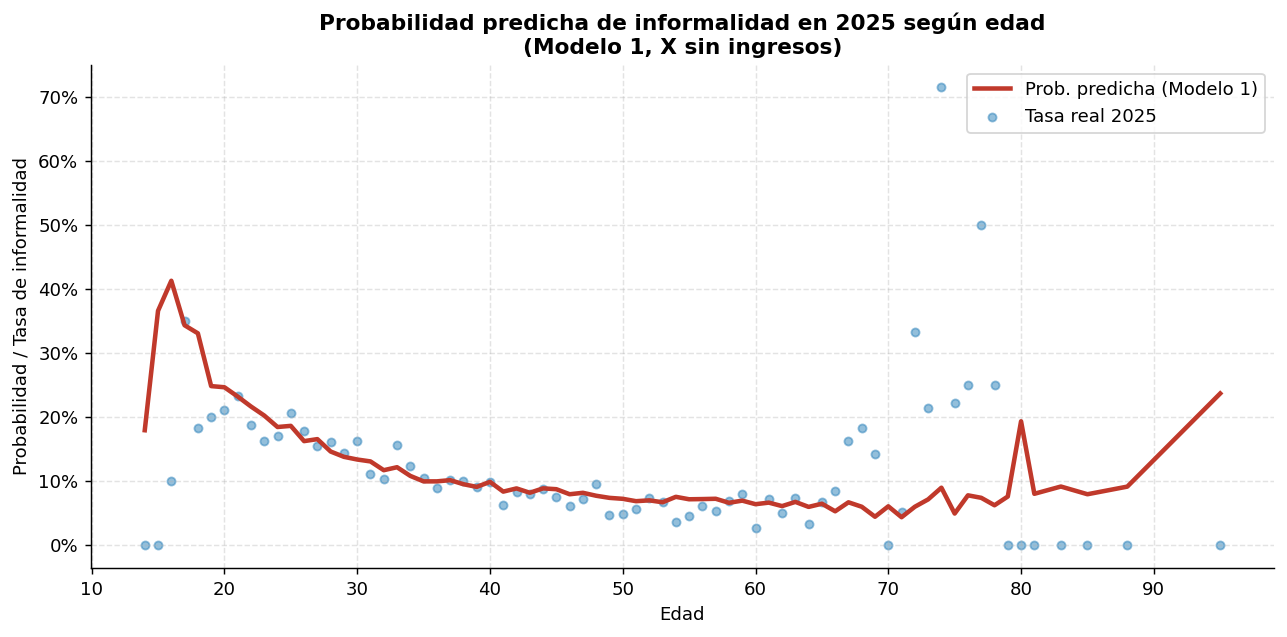

Guardado: TP4_B2_prob_edad.png


In [14]:
Xp = sm.add_constant(ocupados_X_2025, has_constant='add')
df_plot = ocupados_X_2025.copy()
df_plot['prob'] = logit_1.predict(Xp); df_plot['y'] = y_2025.values
pe = df_plot.groupby('edad')[['prob','y']].mean().reset_index()
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(pe['edad'], pe['prob'], color='#C0392B', lw=2.5, label='Prob. predicha (Modelo 1)')
ax.scatter(pe['edad'], pe['y'], color='#2980B9', alpha=0.5, s=20, label='Tasa real 2025')
ax.set_xlabel('Edad'); ax.set_ylabel('Probabilidad / Tasa de informalidad')
ax.set_title('Probabilidad predicha de informalidad en 2025 según edad\n(Modelo 1, X sin ingresos)',
             fontweight='bold')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0)); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(RUTA_OUT,'TP4_B2_prob_edad.png'), dpi=150, bbox_inches='tight')
plt.show(); print('Guardado: TP4_B2_prob_edad.png')

---
## Inciso D — Desempeño y predicción fuera de muestra (umbral p≥0.5)

In [15]:
prob_m1 = logit_1.predict(sm.add_constant(ocupados_X_2025, has_constant='add'))
pred_m1 = (prob_m1>=0.5).astype(int); real_m1 = y_2025.astype(int)
prob_m2 = logit_2.predict(sm.add_constant(ocupados_X_2025_MM[VARS_X_MM], has_constant='add'))
pred_m2 = (prob_m2>=0.5).astype(int); real_m2 = ocupados_X_2025_MM['informal'].astype(int)
print(f'M1 evaluadas: {len(pred_m1):,} | M2 evaluadas: {len(pred_m2):,}')

M1 evaluadas: 13,528 | M2 evaluadas: 4,435


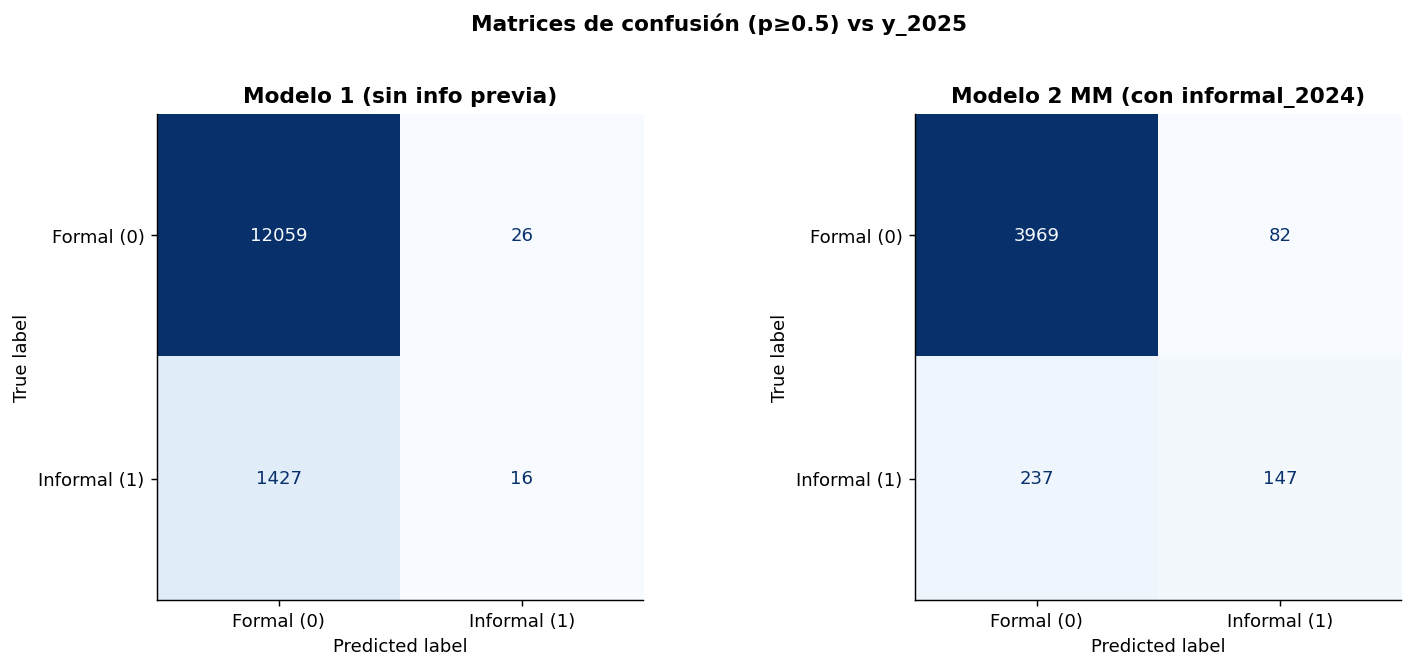

Guardado: TP4_D_confusion.png


In [16]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
for ax, real, pred, tit in zip(axes,[real_m1,real_m2],[pred_m1,pred_m2],
        ['Modelo 1 (sin info previa)','Modelo 2 MM (con informal_2024)']):
    ConfusionMatrixDisplay(confusion_matrix(real,pred), display_labels=['Formal (0)','Informal (1)']
        ).plot(ax=ax, colorbar=False, cmap='Blues'); ax.set_title(tit, fontweight='bold'); ax.grid(False)
plt.suptitle('Matrices de confusión (p≥0.5) vs y_2025', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(os.path.join(RUTA_OUT,'TP4_D_confusion.png'), dpi=150, bbox_inches='tight')
plt.show(); print('Guardado: TP4_D_confusion.png')

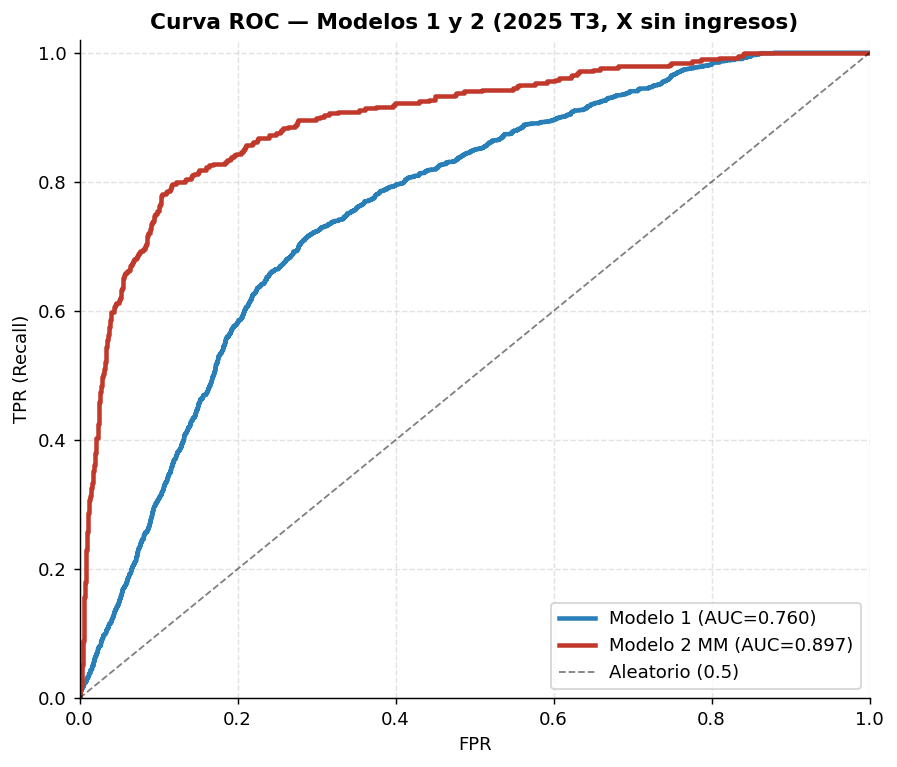

AUC M1: 0.7597 | AUC M2: 0.8974


In [18]:
f1_,t1_,_ = roc_curve(real_m1,prob_m1); f2_,t2_,_ = roc_curve(real_m2,prob_m2)
auc1 = roc_auc_score(real_m1,prob_m1); auc2 = roc_auc_score(real_m2,prob_m2)
fig, ax = plt.subplots(figsize=(7,6))
ax.plot(f1_,t1_,color='#2980B9',lw=2.5,label=f'Modelo 1 (AUC={auc1:.3f})')
ax.plot(f2_,t2_,color='#C0392B',lw=2.5,label=f'Modelo 2 MM (AUC={auc2:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Aleatorio (0.5)')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR (Recall)')
ax.set_title('Curva ROC — Modelos 1 y 2 (2025 T3, X sin ingresos)', fontweight='bold')
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1.02)
plt.tight_layout(); plt.savefig(os.path.join(RUTA_OUT,'TP4_D_roc.png'), dpi=150, bbox_inches='tight')
plt.show(); print(f'AUC M1: {auc1:.4f} | AUC M2: {auc2:.4f}')

In [19]:
def met(real,pred,prob,n):
    return {'Modelo':n,'Accuracy':accuracy_score(real,pred),
            'Precision':precision_score(real,pred,zero_division=0),
            'Recall':recall_score(real,pred,zero_division=0),
            'F1':f1_score(real,pred,zero_division=0),'AUC':roc_auc_score(real,prob)}
tabla_metricas = pd.DataFrame([met(real_m1,pred_m1,prob_m1,'Modelo 1'),
                               met(real_m2,pred_m2,prob_m2,'Modelo 2 MM')]).set_index('Modelo')
print('=== Métricas (umbral p≥0.5) ===\n'); print(tabla_metricas.round(4).to_string())

=== Métricas (umbral p≥0.5) ===

             Accuracy  Precision  Recall     F1    AUC
Modelo                                                
Modelo 1       0.8926     0.3810  0.0111 0.0215 0.7597
Modelo 2 MM    0.9281     0.6419  0.3828 0.4796 0.8974
